# Gender differences across network metrics

Show results for analysis:  
    - Matching acorss efficiency metrics, see `scripts/03_compute_nwmet_matching_byNk.py` 

In [2]:
import pandas as pd
import pickle as pickle
import numpy as np
from scipy import stats
import networkx as nx

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
import matplotlib.lines as mlines

from utils.utils import GENDER, CTRY, COLOR
from utils.utils import set_mpl_style

In [3]:
## Set mpl Style
set_mpl_style()
cm_to_inch = 1/2.54
fs = 7

In [ ]:
## OPEN RESULTS:
input_fig_path = ''
output_fig_path = ''

## --- Matching results across all countries ---
ctry = "all_ctry"
fname = f"{ctry}_res_knn_match.pkl"
with open(input_fig_path + fname, "rb") as f:
    res_knn = pickle.load(f)

## --- Matching results by country ---
dic_RES = {}
for ctry in CTRY:
    fname = f"{ctry}_res_knn_match.pkl"
    with open(input_fig_path + fname, "rb") as f:
        res_ctry = pickle.load(f)
    dic_RES[ctry] = res_ctry


# --- Matching results resampled countries with equal samples ---
ctry = "all_ctry_wequalC"
fname = f"{ctry}_res_knn_match.pkl"
with open(input_fig_path + fname, "rb") as f:
    res_knn_rs = pickle.load(f)

## --- Open Sampled networks ---
with open(input_fig_path + "nw_M_20k_anonym.pkl","rb") as f:
    dic_M_graph = pickle.load(f)

with open(input_fig_path + "nw_F_20k_anonym.pkl","rb") as f:
    dic_F_graph = pickle.load(f)

dic_nw = {'MALE': dic_M_graph, 'FEMALE': dic_F_graph}

In [ ]:
## PLOT NETWORK OF USERS ##
def plot_network(G, ax, node_color = 'mediumseagreen', layout = 'spring',
     k = 0.15, min_size = 10, max_size = 100, edge_length = False, scale_edge_width = True):
    
    weights = [d['weight'] for (n, d) in G.nodes(data=True)]
    scaled_weights = np.exp(weights)  # Exponential scaling, amplifies differences between node weights
    node_sizes = [((w / max(scaled_weights)) * max_size ) + min_size for w in scaled_weights]

    
    # make edge lenght porportional to geo-distance (distance or log_distance)
    if edge_length != False:
        # edge_lengths = {edge: d for edge, d in nx.get_edge_attributes(G, edge_length).items()}
        # print(edge_lengths)
        # pos = nx.spring_layout(G, weight=edge_lengths)
        pos = nx.spring_layout(G, k=k, iterations=200, weight = edge_length)
    else:
        pos = nx.spring_layout(G, k=k, iterations=200)

    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos=pos,  ax=ax,
                        node_color=node_color, node_size=node_sizes, edgecolors='k', linewidths=0.3, alpha = 0.98)

    # Draw edges 
    if scale_edge_width:
        edge_widths = [d['weight']/2 for (u, v, d) in G.edges(data=True)]
        nx.draw_networkx_edges(G, pos=pos,  ax=ax,
                            edge_color='k', alpha=0.8, width=edge_widths)

    else:
        nx.draw_networkx_edges(G, pos=pos,  ax=ax,
                            edge_color='k', alpha=0.8, width=0.5)

In [8]:
## Define Metrics to explore
NW_MLAB = [
    "avg_unw_cluster", 
    "n_cycles",
    "top1_degree_centrality",
    "top2_degree_centrality",
    "top3_degree_centrality",
]
dMLAB = {
    "avg_unw_cluster": "Clustering\ncoefficient",
    "n_cycles": "Number of\ncycles",
    "top1_degree_centrality": "Top 1 degree\ncentrality",
    "top2_degree_centrality": "Top 2 degree\ncentrality",
    "top3_degree_centrality": "Top 3 degree\ncentrality",
}

In [9]:
## Define plot parameters
TEST = [ "all", "inactive", "moderate", "active" ]
dTEST = {"inactive": "inactive (1st–3rd deciles)", "moderate": "moderate (4th–7th)", "active": "active (8th–10th)", "all": "all data"}

dTESTmarker = {
    "inactive": "v",
    "moderate": "d",
    "active": "^",    
    'all': "o",
}
dTESTsize = {
    "inactive": 2,
    "moderate": 2,
    "active": 2,
    'all': 10,
}

verbose = True

In [ ]:
## -- Get Share of countries with significant results
dic_SIGNF = {mlab: {test: {"sig_MALE": 0, "sig_FEMALE": 0, "sig_None": 0} for test in TEST} for mlab in NW_MLAB}
for mlab in NW_MLAB:
    for test in TEST:
        for i, ctry in enumerate(CTRY):
            res_true = dic_RES[ctry][test]["True"]
            res_shuf = dic_RES[ctry][test]["Shuffled"]

            data = 2 * res_true["rel_dif_" + mlab]["mean"]
            shuf_comb = [2 * e["rel_dif_" + mlab]["mean"] for e in res_shuf]
            p5, q1, q3, p95 = np.percentile(shuf_comb, [5, 25, 75, 95])
            # print(mlab, test, ctry, data, p5, q1, q3, p95)

            if data > 0 and data > p95:
                dic_SIGNF[mlab][test]["sig_MALE"] += 1

            elif data < 0 and data < p5:
                dic_SIGNF[mlab][test]["sig_FEMALE"] += 1

            else:
                dic_SIGNF[mlab][test]["sig_None"] += 1

[avg_unw_cluster |    all]  true=-0.0611  pct=  0.0%  p=0.0000  ***
[avg_unw_cluster | inactive]  true=-0.0307  pct=  1.3%  p=0.0320  **
[avg_unw_cluster | moderate]  true=-0.0768  pct=  0.0%  p=0.0000  ***
[avg_unw_cluster | active]  true=-0.0659  pct=  0.0%  p=0.0000  ***
[    n_cycles |    all]  true=-0.0830  pct=  0.0%  p=0.0000  ***
[    n_cycles | inactive]  true=-0.0249  pct=  5.3%  p=0.0920  *
[    n_cycles | moderate]  true=-0.0792  pct=  0.0%  p=0.0000  ***
[    n_cycles | active]  true=-0.0849  pct=  0.0%  p=0.0000  ***
[top1_degree_centrality |    all]  true=-0.0444  pct=  0.0%  p=0.0000  ***
[top1_degree_centrality | inactive]  true=-0.0161  pct=  0.4%  p=0.0080  ***
[top1_degree_centrality | moderate]  true=-0.0486  pct=  0.0%  p=0.0000  ***
[top1_degree_centrality | active]  true=-0.0564  pct=  0.0%  p=0.0000  ***
[top2_degree_centrality |    all]  true=+0.0291  pct=100.0%  p=0.0000  ***
[top2_degree_centrality | inactive]  true=+0.0162  pct= 93.0%  p=0.1400  ns
[top2_de

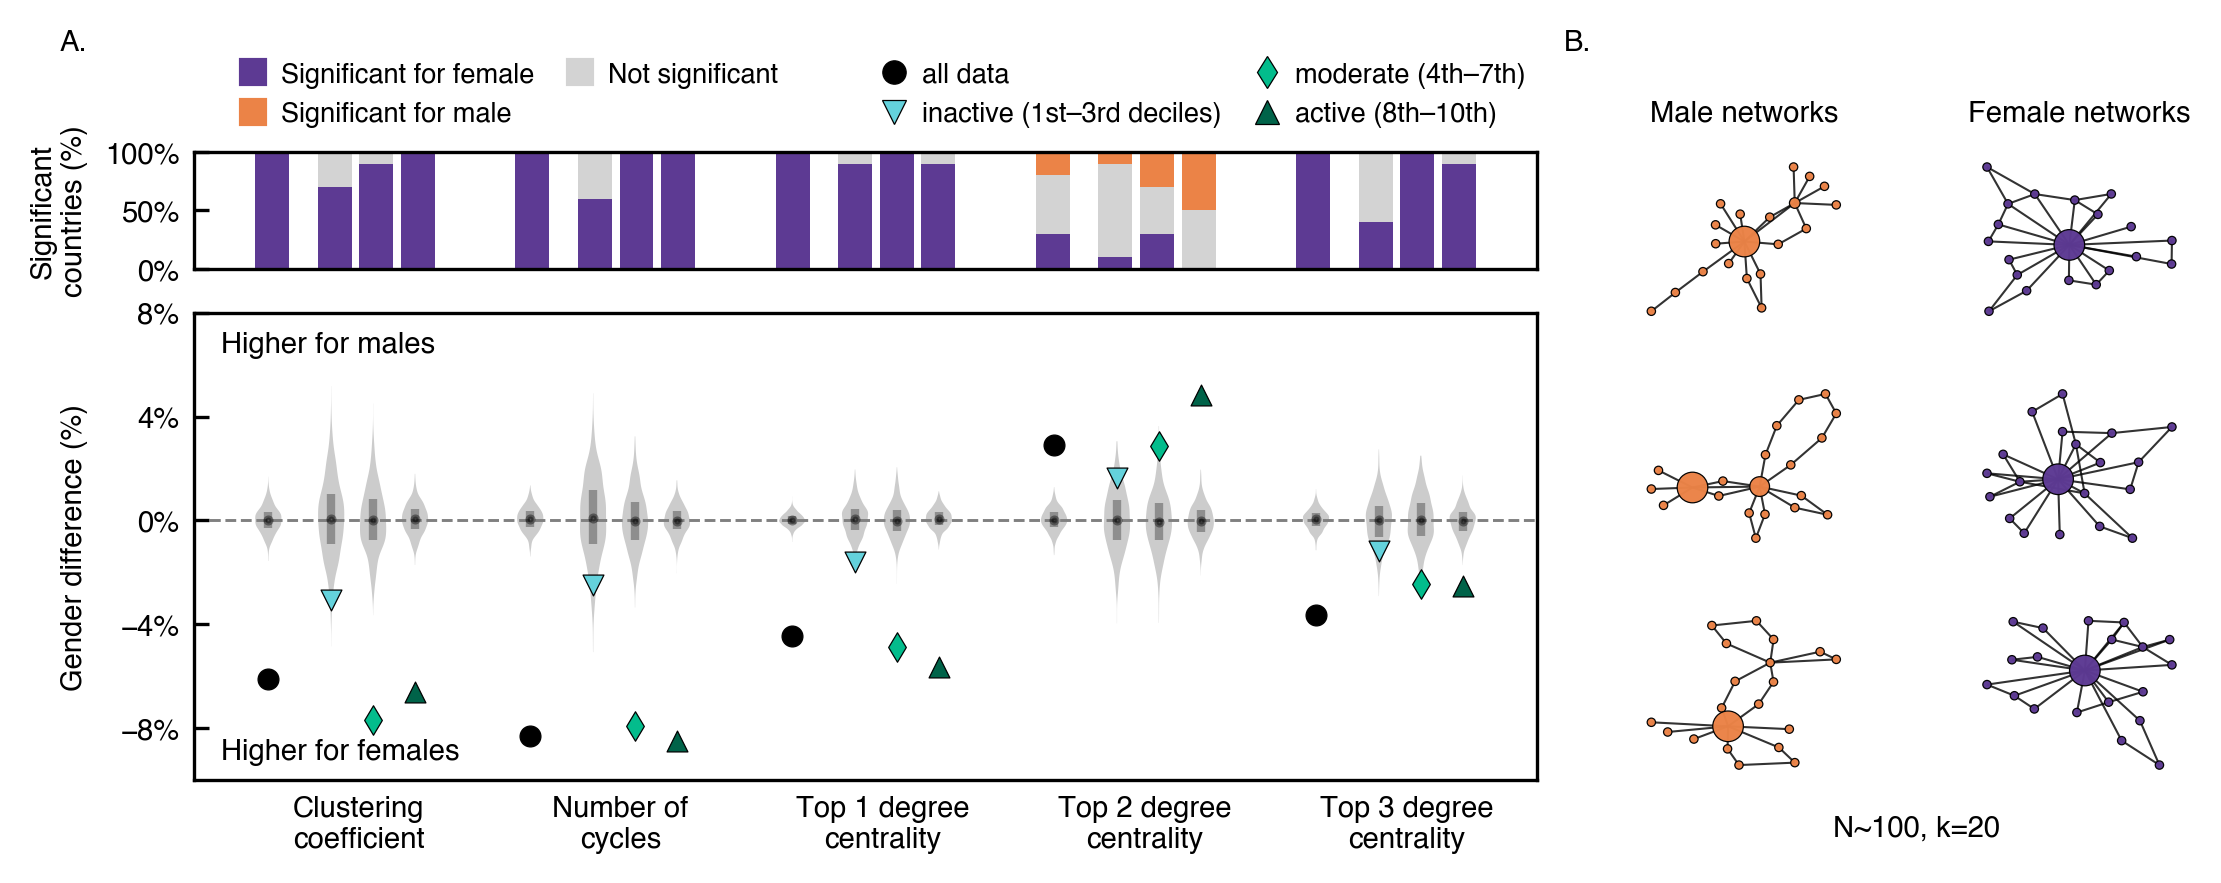

In [ ]:
## PANEL FOR FIGURE
w, h = 18.3 * cm_to_inch, 7 * cm_to_inch
fig = plt.figure(figsize=(w,h), constrained_layout=False)

gs = fig.add_gridspec(2, 2,  height_ratios=[1, 4], width_ratios=[2.4, 1], wspace = 0.1, hspace=0.15)
ax_ctry = fig.add_subplot(gs[0, 0])   
ax_match = fig.add_subplot(gs[1, 0])  

right_gs = gs[:, 1].subgridspec(3, 2, hspace=0.3, wspace=0.5)

ax_nw_M1 = fig.add_subplot(right_gs[0, 0])  
ax_nw_M2 = fig.add_subplot(right_gs[1, 0])  
ax_nw_M3 = fig.add_subplot(right_gs[2, 0])   
ax_nw_F1 = fig.add_subplot(right_gs[0, 1])  
ax_nw_F2 = fig.add_subplot(right_gs[1, 1])  
ax_nw_F3 = fig.add_subplot(right_gs[2, 1])  

# without caption title:
ax_ctry.text(-0.1, 2.05, "A.", transform=ax_ctry.transAxes, va="top", ha="left")
ax_ctry.text(1.02, 2.05, "B.", transform=ax_ctry.transAxes, va="top", ha="left")


## -- A.BOTTOM: Matching results across countries ------------
for i, mlab in enumerate(NW_MLAB):
    met = "rel_dif_" + mlab

    for i_buff, test in enumerate(TEST):

        res_true = res_knn[test]["True"]
        res_shuf = res_knn[test]["Shuffled"]

        data = 2 * res_true[met]["mean"]
        shuf_comb = [2 * e[met]["mean"] for e in res_shuf]

        # -- Percentile validation --
        if verbose:
            percentile_rank = stats.percentileofscore(shuf_comb, data, kind='rank')
            # Two-tailed p-value: what fraction of shuffled values deviated from the median by at least as much as the true value?
            shuf_median = np.median(shuf_comb)
            p_two_tailed = np.mean(np.abs(np.array(shuf_comb) - shuf_median) >= abs(data - shuf_median))
            
            sig_flag = "***" if p_two_tailed < 0.01 else "**" if p_two_tailed < 0.05 else "*" if p_two_tailed < 0.1 else "ns"
            print(f"[{mlab:>12s} | {test:>6s}]  true={data:+.4f}  "
                f"pct={percentile_rank:5.1f}%  p={p_two_tailed:.4f}  {sig_flag}")

        ## --- True difference in match pairs ---
        margin = 0.16 * i_buff if test != "all" else -0.08
        ax_match.scatter(
            i + margin,
            data,
            color=COLOR[test],
            s= 25,
            marker=dTESTmarker[test],
            alpha=1,
            zorder=10,
            edgecolors='black',
            linewidths=0.3
        )
        
        ## --- Randomized baseline ---
        width= 0.1
        parts = ax_match.violinplot(shuf_comb, showmeans=False, showmedians=False, showextrema=False, vert=True,
            positions=[i + margin], widths=width)
        alpha = 0.4
        for pc in parts['bodies']:
            pc.set_facecolor('grey')
            pc.set_alpha(alpha)

        # -- Baseline IQR
        q1, q2, q3 = np.percentile(shuf_comb, [25, 50, 75])
        median = np.median(shuf_comb)
        pos = i +  margin
        ax_match.vlines(pos, q1, q3, color='k', linewidth=2, alpha = 0.3, zorder = 7)
        ax_match.scatter(pos, q2, color='k', s = 2, alpha = 0.4, zorder = 8)


# -- Formatting axes
ax_match.axhline(0, color="grey", linestyle="--", linewidth=0.7, zorder=0)
ax_match.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
ax_match.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5))

ax_match.set_xticks([i + (0.08+3*0.15)/2 for i in range(len(NW_MLAB))])
ax_match.set_xticklabels([dMLAB[mlab] for mlab in NW_MLAB], rotation=0, fontsize=fs)
ax_match.tick_params(axis="x", bottom=True, length=0)


ax_match.set_ylabel("Gender difference (%)", fontsize=fs)
# ax_match.set_xlabel("\nNetwork metrics assessment by activity level", fontsize=fs)

ax_match.set_ylim(-0.1, 0.08)
ax_match.text(0.02, 0.96, "Higher for males", transform=ax_match.transAxes, va="top", ha="left", color='k', fontsize=fs) 
ax_match.text(0.02, 0.09, "Higher for females", transform=ax_match.transAxes, va="top", ha="left", color='k', fontsize=fs)


# -- A.TOP: Matching results by countries ------------
categories = ["sig_FEMALE", "sig_None", "sig_MALE",]
cat_color = {cat: COLOR[cat[4:]] if "None" not in cat else 'lightgrey' for cat in categories}

for i, mlab in enumerate(NW_MLAB):
    for i_buff, test in enumerate(TEST):
        dic_stack = dic_SIGNF[mlab][test]
        tot_values = sum(dic_stack[cat] for cat in categories)
        values = [dic_stack[cat]/tot_values for cat in categories]
        width= 0.13
        alpha = 1
        margin = 0.16 * i_buff if test != "all" else -0.08
        
        pos = i + margin
        bottom = 0
        for cat, val in zip(categories, values):
            bar = ax_ctry.bar(pos, val, width=width, bottom=bottom, label=cat, color=cat_color[cat], alpha=alpha)  
            bottom += val 

ax_ctry.set_xticks([])
ax_ctry.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
ax_ctry.set_ylabel("Significant\ncountries (%)", fontsize=fs)

## -- B: Networks ------------------------
for gen, AXS in {'MALE':[ax_nw_M1, ax_nw_M2, ax_nw_M3], 'FEMALE':[ax_nw_F1, ax_nw_F2, ax_nw_F3]}.items():
    nx_nw = list(dic_nw[gen].values())[1:]
    for i,ax_nw in enumerate(AXS):
        ax_nw.spines.right.set_visible(False)
        ax_nw.spines.left.set_visible(False)
        ax_nw.spines.top.set_visible(False)
        ax_nw.spines.bottom.set_visible(False)
        ax_nw.set_xticks([])
        ax_nw.set_yticks([])

        # Plot networks
        k = 0.1 if gen=='FEMALE' else 0.2
        plot_network(nx_nw[i], ax_nw, node_color = COLOR[gen], layout = 'spring',
            edge_length = 'log_distance', scale_edge_width = False, max_size = 50, min_size = 4, k = k)

ax_nw_M1.text(0.5, 1.3, "Male networks", transform=ax_nw_M1.transAxes, ha="center",  va="top")
ax_nw_F1.text(0.5, 1.3, "Female networks", transform=ax_nw_F1.transAxes, ha="center", va="top")
ax_nw_M3.text(0.9, -0.2, "N~100, k=20", transform=ax_nw_M3.transAxes,  ha="left", va="top")


## -- LEGEND ------------------------
empty_handle = mpl.lines.Line2D([], [], color='none', marker='s', markersize=4, linestyle='None', label="    "*8)
handles = [mpl.lines.Line2D([], [], color=COLOR[gen], marker='s', markersize=4, linestyle='None', label="Significant for " + gen.lower()) for gen in GENDER[::-1]]
handles +=  [mpl.lines.Line2D([], [], color='lightgrey', marker='s', markersize=4, linestyle='None', label='Not significant')] + [empty_handle]*1
handles += [mpl.lines.Line2D([], [], color=COLOR[test], marker=dTESTmarker[test],
     markersize=4, markeredgecolor="black", markeredgewidth=0.3,  linestyle='None', label=dTEST[test]) for test in TEST]

leg = ax_ctry.legend(
    handles=handles,
    loc='lower right',
    bbox_to_anchor=(1.01,1),
    frameon=False,
    ncol=round(len(handles)/2),
    fontsize=fs-0.5,
    handletextpad=0.04,
    columnspacing=0.68, 
    markerscale=1.4,
)
leg._legend_title_box.sep = 20


fig.align_labels()
fig.subplots_adjust(left=0.076, right=1, top=0.85, bottom=0.09)
# plt.savefig(output_fig_path + "fig_2.pdf", bbox_inches=None)
plt.show()

In [ ]:
## S8. Country split
fig, axs = plt.subplots(5, 2, figsize=(18.3 * cm_to_inch, 16 * cm_to_inch), sharey=False, sharex=True)
fig.subplots_adjust(wspace=0.13, hspace=0.3)

for ax_match, ctry in zip(axs.flatten(), CTRY):
    for i, mlab in enumerate(NW_MLAB):
        for i_buff, test in enumerate(TEST):

            res_knn = dic_RES[ctry][test]
            met = "rel_dif_" + mlab
            res_true = res_knn["True"]
            res_shuf = res_knn["Shuffled"]

            data = 2 * res_true[met]["mean"]
            shuf_comb = [2 * e[met]["mean"] for e in res_shuf]

  
            ## --- True difference in match pairs ---
            margin = 0.15 * i_buff if test != "all" else -0.08
            ax_match.scatter(
                i + margin,
                data,
                color=COLOR[test],
                s=6,
                marker=dTESTmarker[test],
                alpha=1,
                zorder=10,
            )
            
            ## --- Randomized baseline ---
            width = 0.1 
            parts = ax_match.violinplot(shuf_comb, showmeans=False, showmedians=False, showextrema=False, vert=True,
                positions=[i + margin], widths=width)
            alpha = 0.3 
            for pc in parts['bodies']:
                pc.set_facecolor('grey')

                pc.set_alpha(alpha)

            # -- Baseline IQR
            q1, q2, q3 = np.percentile(shuf_comb, [25, 50, 75])
            median = np.median(shuf_comb)
            pos = i +  margin
            ax_match.vlines(pos, q1, q3, color='k', linewidth=2, alpha = 0.3, zorder = 7)
            ax_match.scatter(pos, q2, color='k', s = 2, alpha = 0.4, zorder = 8)


    # -- Formatting axes
    
    ax_match.axhline(0, color="grey", linestyle="--", linewidth=0.7, zorder=0)
    ax_match.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
    ax_match.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5))


    ax_match.tick_params(axis="x", bottom=True, length=0)

    ax_match.set_title(ctry, pad=2)


    # --- Alternating background bands per xtick (light yellow / white) ---
    xcenters = [i + (0.08 + 3*0.15)/2 for i in range(len(NW_MLAB))]
    band_halfwidth = 0.5  # 1 category wide

    for j, xc in enumerate(xcenters):
        # draw only the yellow bands; white is just the default bg
        if j % 2 == 0:
            ax_match.axvspan(
                xc - band_halfwidth, xc + band_halfwidth,
                # facecolor="whitesmoke", alpha=1,
                facecolor="gainsboro", alpha=0.5,
                edgecolor="none",
                zorder=-2
            )

    # (optional) ensure full bands are inside the x-limits
    ax_match.set_xlim(xcenters[0] - band_halfwidth, xcenters[-1] + band_halfwidth)



axs[-1, 0].set_xticks([i + (0.08+3*0.15)/2 for i in range(len(NW_MLAB))])
axs[-1, 0].set_xticklabels([dMLAB[mlab] for mlab in NW_MLAB], rotation=0, fontsize=fs-1)

axs[-1, 1].set_xticks([i + (0.08+3*0.15)/2 for i in range(len(NW_MLAB))])
axs[-1, 1].set_xticklabels([dMLAB[mlab] for mlab in NW_MLAB], rotation=0, fontsize=fs-1)


axs[2,0].set_ylabel("Relative difference over the mean   "+ r"$\frac{M-F}{\frac{M+F}{2}}$"+" (%)", fontsize=fs, labelpad=1.5)
fig.supxlabel("\nNetwork metrics assessment by activity level", fontsize=fs, y=0.05)

## -- LEGEND ------------------------
empty_handle = mpl.lines.Line2D([], [], color='none', marker='s', markersize=4, linestyle='None', label="    "*8)

handles = [mpl.lines.Line2D([], [], color=COLOR[test], marker=dTESTmarker[test],
     markersize=4, markeredgecolor="black", markeredgewidth=0.3,  linestyle='None', label=dTEST[test]) for test in TEST]

ncol = len(handles) # round(len(handles)/2)
leg = fig.legend(
    handles=handles,
    loc='lower center',
    bbox_to_anchor=(0.5,0.9),
    frameon=False,
    ncol=ncol,
    fontsize=fs-0.5,
    handletextpad=0.04,
    columnspacing=0.68, 
    markerscale=1.4,
    # title = 'Nearest neighbour matching by activity level\n'
)
leg._legend_title_box.sep = 20


plt.savefig(output_dir + "si_nw_matching_byctry.pdf", bbox_inches="tight")
plt.show()

In [19]:
for i, mlab in enumerate(NW_MLAB):
    for i_buff, test in enumerate(TEST):
        for ctry in CTRY:
            res_knn = dic_RES[ctry][test]
            met = "rel_dif_" + mlab
            res_true = res_knn["True"]
            res_shuf = res_knn["Shuffled"]

            data = 2 * res_true[met]["mean"]
            shuf_comb = [2 * e[met]["mean"] for e in res_shuf]

            # -- Percentile validation --
            if verbose:
                percentile_rank = stats.percentileofscore(shuf_comb, data, kind='rank')
                # Two-tailed p-value: what fraction of shuffled values deviated from the median by at least as much as the true value?
                shuf_median = np.median(shuf_comb)
                p_two_tailed = np.mean(np.abs(np.array(shuf_comb) - shuf_median) >= abs(data - shuf_median))
                
                sig_flag = "***" if p_two_tailed < 0.01 else "**" if p_two_tailed < 0.05 else "*" if p_two_tailed < 0.1 else "ns"
                # print(f"[{mlab:>12s} | {test:>6s}]  true={data:+.4f}  "
                #     f"pct={percentile_rank:5.1f}%  p={p_two_tailed:.4f}  {sig_flag}")

                if sig_flag == "ns":
                    print(f"[{ctry} {mlab:>12s} | {test:>6s}]  true={data:+.4f}  "
                    f"pct={percentile_rank:5.1f}%  p={p_two_tailed:.4f}  {sig_flag}")
                    


[AUS avg_unw_cluster | inactive]  true=-0.0191  pct= 17.4%  p=0.3550  ns
[USA avg_unw_cluster | inactive]  true=-0.0101  pct= 28.0%  p=0.5720  ns
[ESP avg_unw_cluster | inactive]  true=-0.0163  pct= 16.1%  p=0.3120  ns
[USA avg_unw_cluster | moderate]  true=-0.0203  pct= 11.4%  p=0.2200  ns
[NLD     n_cycles | inactive]  true=-0.0269  pct=  9.4%  p=0.1700  ns
[AUS     n_cycles | inactive]  true=-0.0237  pct= 13.6%  p=0.2710  ns
[USA     n_cycles | inactive]  true=+0.0109  pct= 67.0%  p=0.6700  ns
[TWN     n_cycles | inactive]  true=-0.0199  pct= 13.9%  p=0.2680  ns
[ESP top1_degree_centrality | inactive]  true=-0.0013  pct= 43.3%  p=0.8730  ns
[TWN top1_degree_centrality | active]  true=-0.0068  pct=  8.8%  p=0.1780  ns
[NLD top2_degree_centrality |    all]  true=+0.0033  pct= 75.3%  p=0.5160  ns
[AUS top2_degree_centrality |    all]  true=+0.0056  pct= 87.2%  p=0.2580  ns
[FRA top2_degree_centrality |    all]  true=+0.0076  pct= 93.0%  p=0.1320  ns
[SWE top2_degree_centrality |    all